In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("CAR_EVALUATION.csv")

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (1728, 7)
  buying  maint doors persons lug_boot safety Target
0  vhigh  vhigh     2       2    small    low  unacc
1  vhigh  vhigh     2       2    small    med  unacc
2  vhigh  vhigh     2       2    small   high  unacc
3  vhigh  vhigh     2       2      med    low  unacc
4  vhigh  vhigh     2       2      med    med  unacc


In [5]:
print("Columns:")
print(df.columns.tolist())

print("\nTarget classes:")
print(df["Target"].value_counts())

print("\nMissing values:")
print(df.isnull().sum())

Columns:
['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'Target']

Target classes:
Target
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64

Missing values:
buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
Target      0
dtype: int64


In [16]:
# Find-S will consider vgood as the positive class
positive_data = df[df["Target"] == "vgood"].copy()

features = [
    "buying",
    "maint",
    "doors",
    "persons",
    "lug_boot",
    "safety"
]

print("Positive examples:", len(positive_data))
print("\nFirst 10 positive examples:")
print(positive_data[features].head(10))

Positive examples: 65

First 10 positive examples:
     buying maint  doors persons lug_boot safety
1097    med   med      2       4      big   high
1106    med   med      2    more      big   high
1124    med   med      3       4      big   high
1130    med   med      3    more      med   high
1133    med   med      3    more      big   high
1148    med   med      4       4      med   high
1151    med   med      4       4      big   high
1157    med   med      4    more      med   high
1160    med   med      4    more      big   high
1175    med   med  5more       4      med   high


In [17]:
# Start with the most specific hypothesis
hypothesis = ["Ø"] * len(features)

history = []

for _, row in positive_data.iterrows():

    example = [row[feature] for feature in features]

    # First positive example
    if hypothesis == ["Ø"] * len(features):
        hypothesis = example.copy()

    else:
        # Generalize when values are different
        for i in range(len(hypothesis)):
            if hypothesis[i] != example[i]:
                hypothesis[i] = "?"

    history.append(hypothesis.copy())

# Convert history to a DataFrame
history_df = pd.DataFrame(history, columns=features)
history_df.index = range(1, len(history_df) + 1)

print("Hypothesis after each positive example:\n")
print(history_df.head(15))

print("\nFinal Hypothesis:")
print(hypothesis)

Hypothesis after each positive example:

   buying maint doors persons lug_boot safety
1     med   med     2       4      big   high
2     med   med     2       ?      big   high
3     med   med     ?       ?      big   high
4     med   med     ?       ?        ?   high
5     med   med     ?       ?        ?   high
6     med   med     ?       ?        ?   high
7     med   med     ?       ?        ?   high
8     med   med     ?       ?        ?   high
9     med   med     ?       ?        ?   high
10    med   med     ?       ?        ?   high
11    med   med     ?       ?        ?   high
12    med   med     ?       ?        ?   high
13    med   med     ?       ?        ?   high
14    med     ?     ?       ?        ?   high
15    med     ?     ?       ?        ?   high

Final Hypothesis:
['?', '?', '?', '?', '?', 'high']


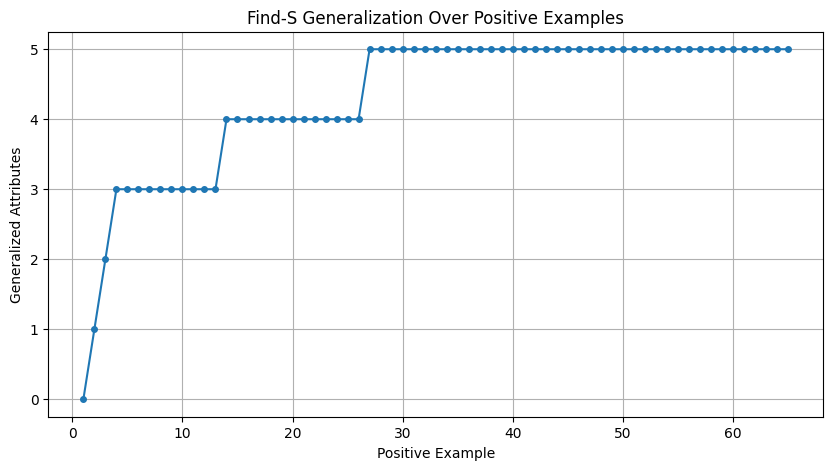

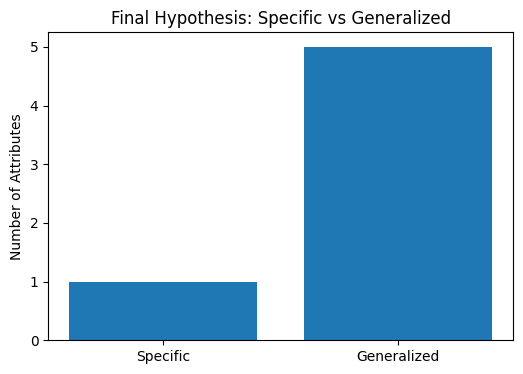

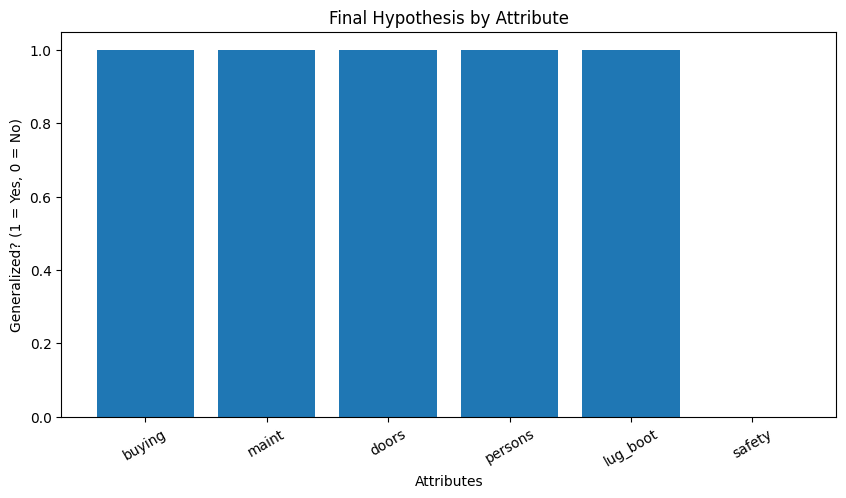

In [18]:
generalized = history_df.apply(
    lambda row: (row == "?").sum(),
    axis=1
)

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(generalized) + 1),
    generalized,
    marker="o",
    markersize=4
)

plt.xlabel("Positive Example")
plt.ylabel("Generalized Attributes")
plt.title("Find-S Generalization Over Positive Examples")

plt.grid(True)
plt.show()
specific = len(hypothesis) - hypothesis.count("?")
generalized = hypothesis.count("?")

plt.figure(figsize=(6, 4))

plt.bar(
    ["Specific", "Generalized"],
    [specific, generalized]
)

plt.title("Final Hypothesis: Specific vs Generalized")
plt.ylabel("Number of Attributes")

plt.figure(figsize=(10, 5))

values = [1 if value == "?" else 0 for value in hypothesis]

plt.bar(features, values)

plt.xlabel("Attributes")
plt.ylabel("Generalized? (1 = Yes, 0 = No)")
plt.title("Final Hypothesis by Attribute")

plt.xticks(rotation=30)

plt.show()